In [2]:
import yfinance as yf
import pandas as pd
import numpy as np

# **PROBABILITY ANALYSIS**

In [3]:
df = pd.read_csv("reversion_signals.csv", index_col=0, parse_dates=True)

In [4]:
df.tail()

,Ratio,Support,Resistance,norm_price,bounce_zone,touch_days_ago,avg_15d_at_touch,norm_avg,approach,signal_v1,block1_pass,block2_pass,final_signal
Date,,,,,,,,,,,,,
2026-08-03,0.592087,0.55,0.60,0.841731,rev res bounce,2.0,0.605502,1.110032,NaN,NaN,NaN,NaN,NaN
2026-08-04,0.600730,0.60,0.65,0.014591,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-05,0.599582,0.55,0.60,0.991632,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-06,0.598114,0.55,0.60,0.962274,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-07,0.601152,0.60,0.65,0.023040,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
probability_df = df[["Ratio","Support","Resistance","final_signal"]]
probability_df.tail()

,Ratio,Support,Resistance,final_signal
Date,,,,
2026-08-03,0.592087,0.55,0.60,NaN
2026-08-04,0.600730,0.60,0.65,NaN
2026-08-05,0.599582,0.55,0.60,NaN
2026-08-06,0.598114,0.55,0.60,NaN
2026-08-07,0.601152,0.60,0.65,NaN


In [6]:
probability_df[probability_df["final_signal"] == "reverting from support"].shape

(21, 4)

In [7]:
probability_df[probability_df["final_signal"] == "reverting from resistance"].shape

(15, 4)

## **MFE and MAE**
MFE (Maximum Favorable Excursion) & MAE (Maximum Adverse Excursion)

In [42]:
def add_mfe_mae(df, period=20):
    df = df.copy()
    
    mfe_list = []
    mae_list = []
    
    for i in range(len(df)):
        signal = df["final_signal"].iloc[i]
        
        if pd.isna(signal):
            mfe_list.append(None)
            mae_list.append(None)
            continue
        
        if i + period >= len(df):
            mfe_list.append(None)
            mae_list.append(None)
            continue
        
        price_now = df["Ratio"].iloc[i]
        path_returns = []
        
        for day in range(1, period + 1):
            future_price = df["Ratio"].iloc[i + day]
            raw_return = (future_price - price_now) / price_now * 100
            
            if signal == "reverting from resistance":
                directional_return = -raw_return
            else:
                directional_return = raw_return
            
            path_returns.append(directional_return)
        
        mfe_list.append(max(path_returns))
        mae_list.append(min(path_returns))
    
    df["MFE"] = mfe_list
    df["MAE"] = mae_list
    return df

In [53]:

probability_df = add_mfe_mae(probability_df, period=20)

In [58]:
#df[~df["final_signal"].isna()].tail(10)

mae_mfe_df =  probability_df[~probability_df["final_signal"].isna()]

In [62]:
df = mae_mfe_df.copy()

df["prev_date"] = df.index.to_series().shift(1)

df["date_gap"] = (df.index.to_series() - df["prev_date"]).dt.days

df["is_new_trade"] = df["date_gap"].isna() | (df["date_gap"] > 3)

df_deduped = df[df["is_new_trade"]]

df_deduped

,Ratio,Support,Resistance,final_signal,MFE,MAE,prev_date,date_gap,is_new_trade
Date,,,,,,,,,
2022-12-02,0.919541,0.90,1.05,reverting from support,1.438803,-1.296935,NaT,NaN,True
2023-02-21,0.887370,0.80,0.90,reverting from resistance,0.830929,-1.278561,2022-12-06,77.0,True
2023-02-27,0.889719,0.80,0.90,reverting from resistance,3.907190,-1.011196,2023-02-22,5.0,True
2023-03-07,0.886669,0.80,0.90,reverting from resistance,3.748913,-1.219516,2023-02-27,8.0,True
2023-09-11,0.868341,0.80,0.90,reverting from resistance,6.854912,1.310252,2023-03-07,188.0,True
2023-10-18,0.812861,0.80,0.90,reverting from support,3.178247,-0.207558,2023-09-11,37.0,True
2023-11-22,0.812008,0.80,0.90,reverting from support,4.844208,0.231042,2023-10-23,30.0,True
2024-04-02,0.793880,0.75,0.80,reverting from resistance,5.918299,-0.697698,2023-11-24,130.0,True
2024-05-09,0.759018,0.75,0.80,reverting from support,-0.023178,-6.719285,2024-04-04,35.0,True


In [67]:
summary = df_deduped.groupby("final_signal")[["MFE", "MAE"]].agg(["mean", "median"])
summary = summary.round(1)
summary

MFE         MAE       
                          mean median mean median
final_signal                                     
reverting from resistance  3.9    3.7 -1.1   -1.2
reverting from support     3.5    3.2 -1.7   -1.3

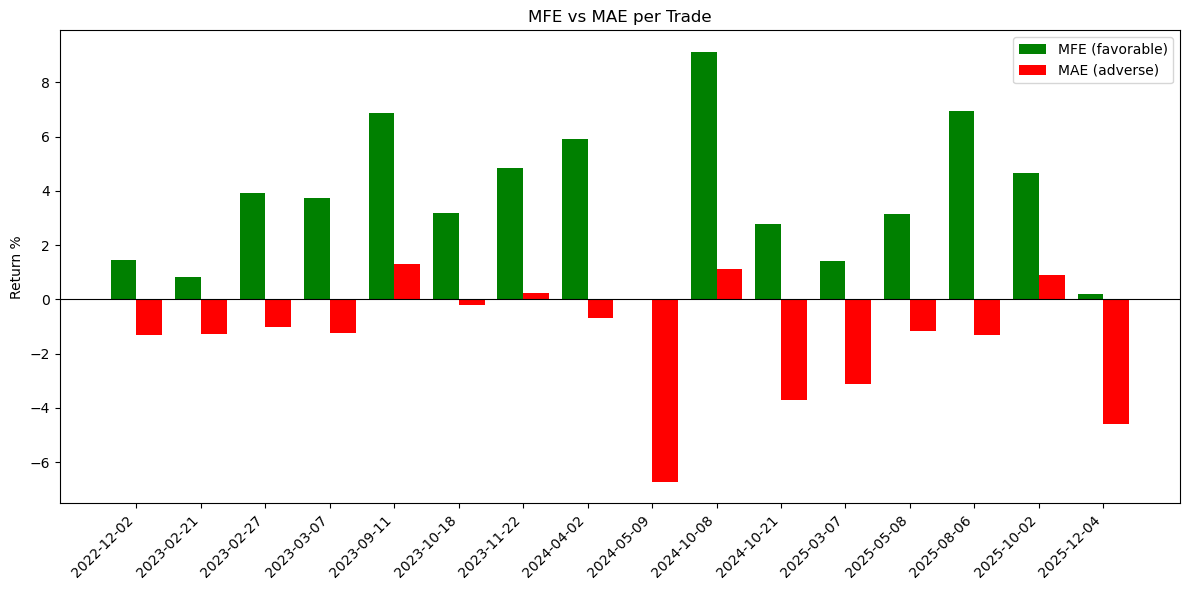

In [68]:
import matplotlib.pyplot as plt
import numpy as np

# use the deduped dataframe
plot_df = df_deduped.dropna(subset=["MFE", "MAE"])

x = np.arange(len(plot_df))
width = 0.4

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - width/2, plot_df["MFE"], width, label="MFE (favorable)", color="green")
ax.bar(x + width/2, plot_df["MAE"], width, label="MAE (adverse)", color="red")

ax.axhline(0, color="black", linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index.strftime("%Y-%m-%d"), rotation=45, ha="right")

ax.set_ylabel("Return %")
ax.set_title("MFE vs MAE per Trade")
ax.legend()

plt.tight_layout()
plt.show()